In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText

,ID ANSSI,Titre ANSSI,Type,Date,CVE,CVSS,Base Severity,CWE,EPSS,Lien,Description,Éditeur,Produit,Versions affectées
0,CERTFR-2026-AVI-0692,Multiples vulnérabilités dans Google Chrome (0...,Avis,2026-06-05 00:00:00+00:00,CVE-2026-10985,NaN,Non disponible,CWE-125,0.00035,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Out of bounds read in Skia in Google Chrome pr...,Google,Chrome,149.0.7827.53
1,CERTFR-2026-AVI-0692,Multiples vulnérabilités dans Google Chrome (0...,Avis,2026-06-05 00:00:00+00:00,CVE-2026-10989,NaN,Non disponible,Non disponible,0.00086,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Inappropriate implementation in V8 in Google C...,Google,Chrome,149.0.7827.53
2,CERTFR-2026-AVI-0692,Multiples vulnérabilités dans Google Chrome (0...,Avis,2026-06-05 00:00:00+00:00,CVE-2026-11109,NaN,Non disponible,CWE-457,0.00030,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Uninitialized Use in ANGLE in Google Chrome pr...,Google,Chrome,149.0.7827.53
3,CERTFR-2026-AVI-0692,Multiples vulnérabilités dans Google Chrome (0...,Avis,2026-06-05 00:00:00+00:00,CVE-2026-11163,NaN,Non disponible,CWE-416,0.00073,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Use after free in Messages in Google Chrome on...,Google,Chrome,149.0.7827.53
4,CERTFR-2026-AVI-0692,Multiples vulnérabilités dans Google Chrome (0...,Avis,2026-06-05 00:00:00+00:00,CVE-2026-10934,NaN,Non disponible,CWE-416,0.00073,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Use after free in Autofill in Google Chrome on...,Google,Chrome,149.0.7827.53


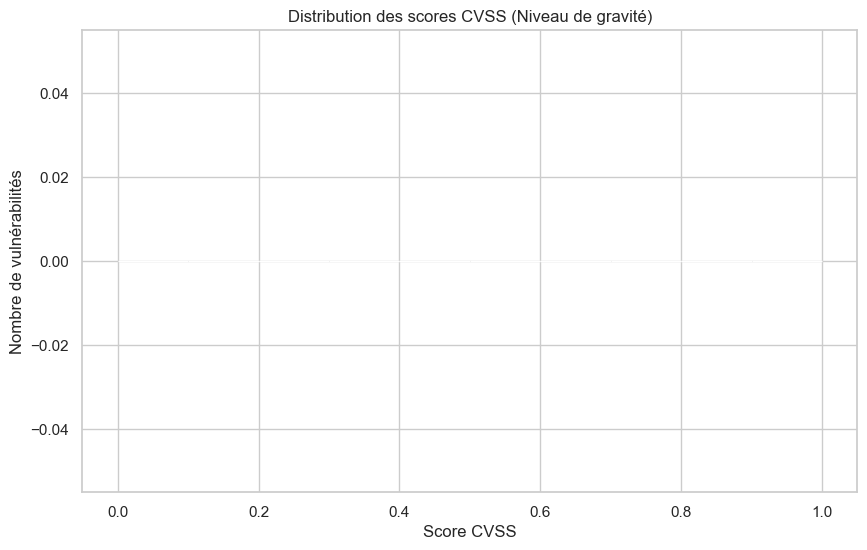

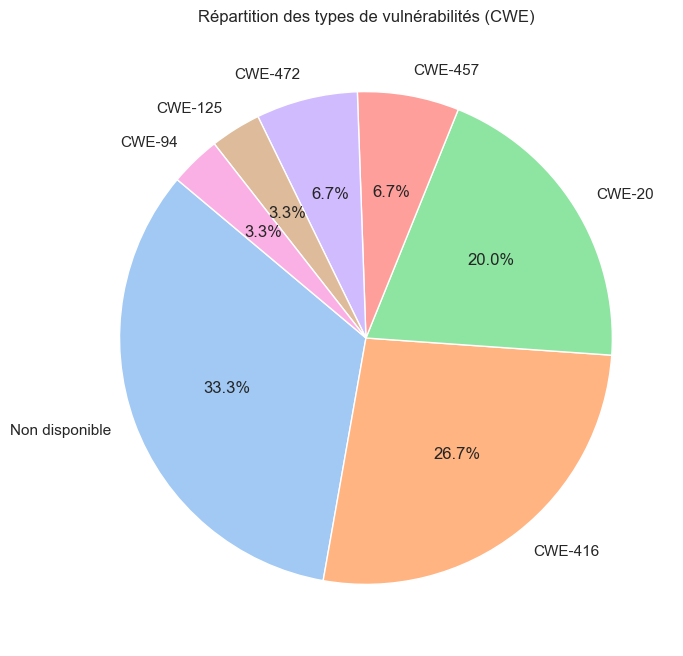

C:\Users\Timothée\AppData\Local\Temp\ipykernel_11472\2083269720.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Éditeur', order=df['Éditeur'].value_counts().index, palette='viridis')


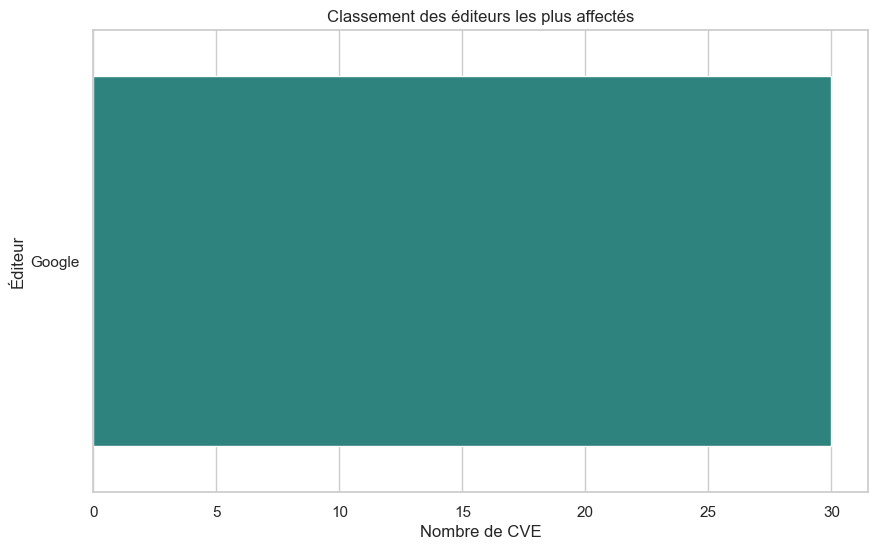

In [11]:
df = pd.read_csv('donnees_anssi_enrichies.csv',sep=',')

display(df.head())

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['CVSS'], bins=10, kde=True, color='crimson')
plt.title('Distribution des scores CVSS (Niveau de gravité)')
plt.xlabel('Score CVSS')
plt.ylabel('Nombre de vulnérabilités')
plt.show()

plt.figure(figsize=(8, 8))
cwe_counts = df['CWE'].value_counts()
plt.pie(cwe_counts, labels=cwe_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Répartition des types de vulnérabilités (CWE)')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Éditeur', order=df['Éditeur'].value_counts().index, palette='viridis')
plt.title('Classement des éditeurs les plus affectés')
plt.xlabel('Nombre de CVE')
plt.ylabel('Éditeur')
plt.show()


[Modèle Non Supervisé : K-Means Clustering]


c:\testanaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


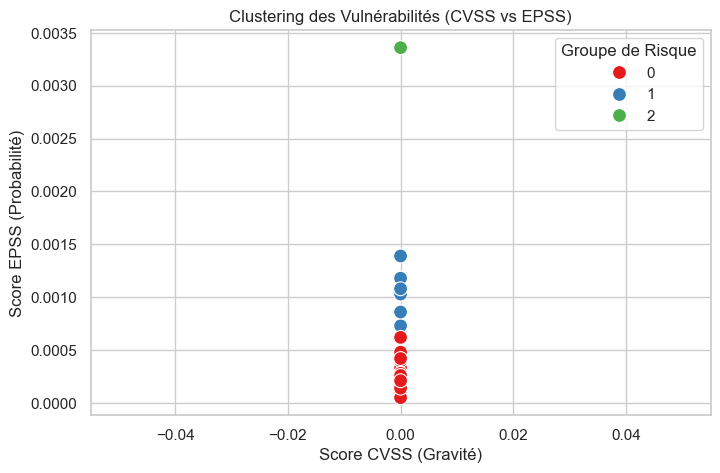


[Modèle Supervisé : Random Forest Regressor]
Validation du modèle :
- Erreur Quadratique Moyenne (MSE) : 0.0000
- Score R2 : -0.0828


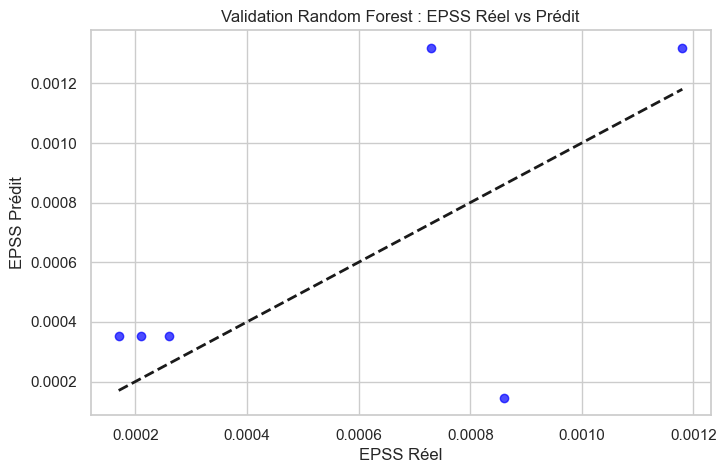

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

df_ml = df.copy()

le_cwe = LabelEncoder()
df_ml['CWE_encoded'] = le_cwe.fit_transform(df_ml['CWE'])

df_ml.fillna(0, inplace=True)


print("\n[Modèle Non Supervisé : K-Means Clustering]")
X_unsup = df_ml[['CVSS', 'EPSS']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['Cluster_Risque'] = kmeans.fit_predict(X_unsup)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_ml, x='CVSS', y='EPSS', hue='Cluster_Risque', palette='Set1', s=100)
plt.title("Clustering des Vulnérabilités (CVSS vs EPSS)")
plt.xlabel("Score CVSS (Gravité)")
plt.ylabel("Score EPSS (Probabilité)")
plt.legend(title='Groupe de Risque')
plt.show()


print("\n[Modèle Supervisé : Random Forest Regressor]")
X_sup = df_ml[['CVSS', 'CWE_encoded']]
y_sup = df_ml['EPSS']

X_train, X_test, y_train, y_test = train_test_split(X_sup, y_sup, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Validation du modèle :")
print(f"- Erreur Quadratique Moyenne (MSE) : {mse:.4f}")
print(f"- Score R2 : {r2:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Ligne de perfection
plt.title("Validation Random Forest : EPSS Réel vs Prédit")
plt.xlabel("EPSS Réel")
plt.ylabel("EPSS Prédit")
plt.show()

In [7]:
from_email = 'alertes.td.final@gmail.com'
password = 'zfjw jnhx jpks jxkf'

In [13]:
def send_email(to_email, subject, body):
    
    msg = MIMEText(body) 
    msg['From'] = from_email 
    msg['To'] = to_email
    msg['Subject'] = subject
    
    try:
        server = smtplib.SMTP('smtp.gmail.com', 587) 
        server.starttls() 
        server.login(from_email, password) 
        server.sendmail(from_email, to_email, msg.as_string())
        server.quit()
        print(f"Alerte envoyée avec succès à {to_email}")
    except Exception as e:
        print(f"Erreur lors de l'envoi de l'email : {e}")

def verifier_et_alerter(df, email_destinataire):
    alertes_critiques = df[df['CVSS'] >= 9.0]
    
    if alertes_critiques.empty:
        print("Aucune vulnérabilité critique détectée. Aucun email envoyé.")
        return
        
    for index, row in alertes_critiques.iterrows():
        sujet = f"Alerte CVE critique : {row['CVE']} sur {row['Produit']}"
        
        corps = f"""
        Bonjour,
        
        Une vulnérabilité critique a été publiée par l'ANSSI.
        
        Détails :
        - Produit affecté : {row['Produit']} (Éditeur : {row['Éditeur']})
        - CVE : {row['CVE']}
        - Score CVSS : {row['CVSS']} ({row['Base Severity']})
        - Probabilité d'exploitation (EPSS) : {row['EPSS']}
        
        Description :
        {row['Description']}
        
        Lien ANSSI : {row['Lien']}
        
        Veuillez patcher vos systèmes (Versions affectées : {row['Versions affectées']}) immédiatement.
        """
        
        print("--- PRÉPARATION DE L'ALERTE ---")
        print(f"Sujet : {sujet}")
        print(f"Corps : {corps}")
        
        send_email(email_destinataire,sujet,corps)
        
verifier_et_alerter(df,'timotheerobin48@gmail.com')

Aucune vulnérabilité critique détectée. Aucun email envoyé.
